FileNotFoundError: [Errno 2] No such file or directory: '/user/ab5405/summeraliaclimate/code/mortality_pipeline/output/age_combined_ALLREA/pooled_response_spec2_ERA5_025_prodint.csvv'

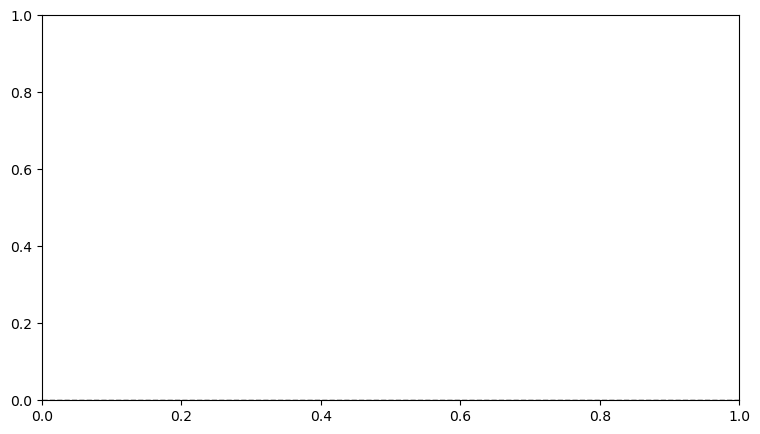

In [4]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

CSVV_DIR = Path("/user/ab5405/summeraliaclimate/code/mortality_p/output/age_combined_ALLREA")
PRODUCTS = ["ERA5_025", "GMFD", "MERRA2", "JRA_3Q"]
TMIN, TMAX = -15.0, 45.0
SLICE_MIN, SLICE_MAX = 10.0, 25.0
N_DRAWS = 800
RNG = np.random.default_rng(123)

PROD_STYLE = {
    "ERA5_025": dict(label="ERA5-025", color="#1f77b4"),
    "GMFD":     dict(label="GMFD",     color="#2ca02c"),
    "MERRA2":   dict(label="MERRA-2",  color="#ff7f0e"),
    "JRA_3Q":   dict(label="JRA-3Q",   color="#9467bd"),
}

def read_gamma_and_vcv(path):
    txt = Path(path).read_text()
    _F = r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[Ee][-+]?\d+)?"
    g = re.search(r"\bgamma\s*(.*?)\bgammavcv\b", txt, flags=re.S|re.I)
    v = re.search(r"\bgammavcv\b(.*)\Z",           txt, flags=re.S|re.I)
    gamma = np.array([float(x) for x in re.findall(_F, g.group(1))][:4])
    vcv   = np.array([float(x) for x in re.findall(_F, v.group(1))][:16]).reshape(4,4)
    return gamma, vcv

T    = np.linspace(TMIN, TMAX, 800)
Tpow = np.vstack([T, T**2, T**3, T**4])

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color="k", ls="--", lw=1)

for prod in PRODUCTS:
    path = CSVV_DIR / f"pooled_response_spec2_{prod}_prodint.csvv"
    gamma, vcv = read_gamma_and_vcv(path)
    draws = RNG.multivariate_normal(gamma, vcv, size=N_DRAWS)
    y_raw = draws @ Tpow
    win  = (T >= SLICE_MIN) & (T <= SLICE_MAX)
    y    = y_raw - np.nanmin(y_raw[:, win], axis=1)[:, None]
    y_mean = np.nanmean(y, axis=0)
    y_lo, y_hi = np.nanpercentile(y, [5, 95], axis=0)
    s = PROD_STYLE[prod]
    ax.plot(T, y_mean, lw=2.5, **s)
    ax.fill_between(T, y_lo, y_hi, alpha=0.12, color=s["color"], linewidth=0)

ax.set_xlabel("Temperature [°C]")
ax.set_ylabel("Δ deaths per 100k")
ax.set_title("Age-combined response functions: Spec 2, all products (ALLREA pooled)")
ax.legend(frameon=True, fontsize=9)
ax.margins(x=0)
ax.grid(False)
plt.tight_layout()
plt.show()